# **Baseball Salary Analysis (Assignment 1)**

**Purpose:** Identify and explain 10 interesting findings about MLB player salaries using at least five analytic methods (descriptive statistics, charts, crosstabs, correlation, hypothesis tests, ANOVA, and regression).

## 1. Setup

In [55]:
from pathlib import Path
import re
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

BASE_OUT = Path("outputs")
DIRS = {
    "tables": BASE_OUT / "tables",
    "figures": BASE_OUT / "figures",
    "models": BASE_OUT / "models",
    "appendix": BASE_OUT / "appendix",
}

RESET_OUTPUTS_EACH_RUN = True

if RESET_OUTPUTS_EACH_RUN and BASE_OUT.exists():
    shutil.rmtree(BASE_OUT)

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TABLE_NO = 0
FIG_NO = 0

def _slugify(text: str, max_len: int = 90) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"[\s_-]+", "_", text)
    return text[:max_len].strip("_") or "output"

def _ensure_suffix(name: str, suffix: str) -> str:
    return name if name.lower().endswith(suffix.lower()) else f"{name}{suffix}"

def _as_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def format_currency(x):
    if pd.isna(x):
        return ""
    try:
        return f"${float(x):,.2f}"
    except Exception:
        return x

def format_number(x, decimals=2):
    if pd.isna(x):
        return ""
    try:
        return f"{float(x):,.{decimals}f}"
    except Exception:
        return x

def display_titled_table(
    df: pd.DataFrame,
    title: str,
    filename: str,
    *,
    folder: str = "tables",
    currency_cols=None,
    decimals: int = 2,
    corr_cols=None,
    index: bool = True,
    extra_style=None,
):
    global TABLE_NO
    TABLE_NO += 1

    df_out = df.copy()
    currency_cols = set(currency_cols or [])
    corr_cols = set(corr_cols or [])

    formatter = {}
    for col in df_out.columns:
        if col in currency_cols:
            formatter[col] = format_currency
        elif col in corr_cols:
            formatter[col] = lambda v: format_number(v, 3)
        elif col.lower() == "count":
            formatter[col] = lambda v: format_number(v, 0)
        elif pd.api.types.is_numeric_dtype(df_out[col]):
            formatter[col] = lambda v, d=decimals: format_number(v, d)

    base_styles = [
        {"selector": "caption",
         "props": [("caption-side", "top"),
                   ("font-weight", "700"),
                   ("font-size", "13px"),
                   ("text-align", "left"),
                   ("padding", "6px 0px")]},
        {"selector": "table",
         "props": [("border-collapse", "collapse"),
                   ("font-family", "Arial"),
                   ("font-size", "11px"),
                   ("width", "100%")]},
        {"selector": "th",
         "props": [("background-color", "#E6E6E6"),
                   ("border-top", "2px solid #333333"),
                   ("border-bottom", "2px solid #333333"),
                   ("padding", "6px 8px"),
                   ("text-align", "center")]},
        {"selector": "td",
         "props": [("border-top", "1px solid #BFBFBF"),
                   ("border-bottom", "1px solid #BFBFBF"),
                   ("padding", "6px 8px"),
                   ("text-align", "center")]},
    ]

    caption = f"Table {TABLE_NO}. {title}"

    styled = (
        df_out.style
        .set_caption(caption)
        .set_table_styles(base_styles)
        .format(formatter)
    )

    if extra_style is not None:
        styled = styled.apply(extra_style, axis=None)

    display(HTML(styled.to_html()))

    out_dir = DIRS.get(folder, DIRS["tables"])
    base = f"table_{TABLE_NO:02d}_{_slugify(filename)}"
    csv_path = out_dir / _ensure_suffix(base, ".csv")
    html_path = out_dir / _ensure_suffix(base, ".html")

    df_out.to_csv(csv_path, index=index)
    styled.to_html(html_path)

    return {"table_no": TABLE_NO, "csv": csv_path, "html": html_path}

def save_figure(
    title: str,
    filename: str,
    *,
    folder: str = "figures",
    fig=None,
    ax=None,
    show: bool = True,
):
    global FIG_NO
    FIG_NO += 1

    if fig is None:
        fig = plt.gcf()
    if ax is None:
        ax = plt.gca()

    ax.set_title(f"Figure {FIG_NO}. {title}", pad=10)
    fig.tight_layout()

    out_dir = DIRS.get(folder, DIRS["figures"])
    base = f"fig_{FIG_NO:02d}_{_slugify(filename)}"
    png_path = out_dir / _ensure_suffix(base, ".png")

    fig.savefig(png_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    return {"fig_no": FIG_NO, "png": png_path}

def save_text_output(text: str, filename: str, *, folder: str = "models"):
    out_dir = DIRS.get(folder, DIRS["models"])
    path = out_dir / _ensure_suffix(_slugify(filename), ".txt")
    path.write_text(text, encoding="utf-8")
    return path

def save_dataframe(df: pd.DataFrame, filename: str, *, folder: str = "tables", index: bool = True):
    out_dir = DIRS.get(folder, DIRS["tables"])
    path = out_dir / _ensure_suffix(_slugify(filename), ".csv")
    df.to_csv(path, index=index)
    return path

print("Output folders ready:")
for k, v in DIRS.items():
    print(f"- {k}: {v.as_posix()}")

Output folders ready:
- tables: outputs/tables
- figures: outputs/figures
- models: outputs/models
- appendix: outputs/appendix


## 2. Load Data

In [56]:
from google.colab import files

print("Please upload the baseball salary Excel file.")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df_raw = pd.read_excel(file_name)
df = df_raw.copy()

print("Loaded:", file_name)
print("Shape:", df.shape)

Please upload the baseball salary Excel file.


Saving Baseball salary.xlsx to Baseball salary (5).xlsx
Loaded: Baseball salary (5).xlsx
Shape: (322, 22)


## 3. Quick Data Audit

In [57]:
_ = display_titled_table(df.head(10), "First 10 Rows (Raw Input)", "raw_first_10", folder="appendix", index=False)

desc = df.describe(include="all").transpose()
_ = display_titled_table(desc, "Data Dictionary Summary (describe)", "describe_all", folder="appendix", index=True)

missing = df.isna().sum().sort_values(ascending=False).to_frame("Missing")
_ = display_titled_table(missing, "Missing Values by Column", "missing_by_column", folder="appendix", index=True)

,NAME,TEAM,NO_ATBAT,NO_HITS,NO_HOME,NO_RUNS,NO_RBI,NO_BB,YR_MAJOR,CR_ATBAT,CR_HITS,CR_HOME,CR_RUNS,CR_RBI,CR_BB,LEAGUE,DIVISION,POSITION,NO_OUTS,NO_ASSTS,NO_ERROR,SALARY
0,"Thomas, Andres",Atlanta,323.00,81.00,6.00,26.00,32.00,8.00,2.00,341.00,86.00,6.00,32.00,34.00,8.00,National,West,SS,143.00,290.00,19.00,75.00
1,"Harper, Terry",Atlanta,265.00,68.00,8.00,26.00,30.00,29.00,7.00,"1,337.00",339.00,32.00,135.00,163.00,128.00,National,West,OF,92.00,5.00,3.00,425.00
2,"Simmons, Ted",Atlanta,127.00,32.00,4.00,14.00,25.00,12.00,19.00,"8,396.00","2,402.00",242.00,"1,048.00","1,348.00",819.00,National,West,UT,167.00,18.00,6.00,500.00
3,"Hubbard, Glenn",Atlanta,408.00,94.00,4.00,42.00,36.00,66.00,9.00,"3,573.00",866.00,59.00,429.00,365.00,410.00,National,West,2B,282.00,487.00,19.00,535.00
4,"Virgil, Ozzie",Atlanta,359.00,80.00,15.00,45.00,48.00,63.00,7.00,"1,493.00",359.00,61.00,176.00,202.00,175.00,National,West,C,682.00,93.00,13.00,700.00
5,"Oberkfell, Ken",Atlanta,503.00,136.00,5.00,62.00,48.00,83.00,10.00,"3,423.00",970.00,20.00,408.00,303.00,414.00,National,West,3B,65.00,258.00,8.00,725.00
6,"Ramirez, Rafael",Atlanta,496.00,119.00,8.00,57.00,33.00,21.00,7.00,"3,358.00",882.00,36.00,365.00,280.00,165.00,National,West,S3,155.00,371.00,29.00,875.00
7,"Murphy, Dale",Atlanta,614.00,163.00,29.00,89.00,83.00,75.00,11.00,"5,017.00","1,388.00",266.00,813.00,822.00,617.00,National,West,CF,303.00,6.00,6.00,"1,900.00"
8,"Horner, Bob",Atlanta,517.00,141.00,27.00,70.00,87.00,52.00,9.00,"3,571.00",994.00,215.00,545.00,652.00,337.00,National,West,1B,"1,378.00",102.00,8.00,199.00
9,"Moreno, Omar",Atlanta,359.00,84.00,4.00,46.00,27.00,21.00,12.00,"4,992.00","1,257.00",37.00,699.00,386.00,387.00,National,West,RF,151.00,8.00,5.00,250.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NAME,322,322,"Whitt, Ernie",1,nan,nan,nan,nan,nan,nan,nan
TEAM,322,23,NewYork,32,nan,nan,nan,nan,nan,nan,nan
NO_ATBAT,322,nan,nan,nan,390.074534,143.595835,127.000000,272.000000,390.500000,512.750000,687.000000
NO_HITS,322,nan,nan,nan,103.397516,44.179509,31.000000,68.000000,98.500000,137.750000,238.000000
NO_HOME,322,nan,nan,nan,11.102484,8.698770,0.000000,4.000000,8.500000,16.000000,40.000000
NO_RUNS,322,nan,nan,nan,52.217391,25.057366,12.000000,32.000000,48.000000,70.000000,130.000000
NO_RBI,322,nan,nan,nan,49.372671,25.501162,8.000000,29.000000,45.000000,65.000000,121.000000
NO_BB,322,nan,nan,nan,39.857143,21.095941,3.000000,22.000000,35.500000,54.000000,105.000000
YR_MAJOR,322,nan,nan,nan,7.680124,4.969707,1.000000,4.000000,6.000000,11.000000,24.000000
CR_ATBAT,322,nan,nan,nan,2763.077640,2328.479167,166.000000,911.250000,2065.000000,4068.500000,14053.000000


,Missing
NAME,0.00
TEAM,0.00
NO_ATBAT,0.00
NO_HITS,0.00
NO_HOME,0.00
NO_RUNS,0.00
NO_RBI,0.00
NO_BB,0.00
YR_MAJOR,0.00
CR_ATBAT,0.00


## 4. Data Quality Diagnostics

This section flags potential data entry inconsistencies in LEAGUE, TEAM, and POSITION.
It does not modify the dataset used for statistical analysis.

In [58]:
from difflib import get_close_matches

df_diag = df_raw.copy()

df_diag["TEAM"] = df_diag["TEAM"].astype(str).str.strip().str.replace(" ", "", regex=False)
df_diag["LEAGUE"] = df_diag["LEAGUE"].astype(str).str.strip().str.title()
df_diag["DIVISION"] = df_diag["DIVISION"].astype(str).str.strip().str.title()
df_diag["POSITION"] = df_diag["POSITION"].astype(str).str.strip().str.upper()

canonical_team_league = {
    "Baltimore": "American",
    "Boston": "American",
    "NewYork": None,
    "TampaBay": "American",
    "Toronto": "American",
    "Cleveland": "American",
    "Detroit": "American",
    "Chicago": None,
    "KansasCity": "American",
    "Minnesota": "American",
    "Oakland": "American",
    "Houston": "American",
    "LosAngeles": None,
    "Seattle": "American",
    "Texas": "American",
    "Atlanta": "National",
    "Miami": "National",
    "Philadelphia": "National",
    "Washington": "National",
    "Cincinnati": "National",
    "Pittsburgh": "National",
    "Milwaukee": "National",
    "StLouis": "National",
    "Arizona": "National",
    "Colorado": "National",
    "SanDiego": "National",
    "SanFrancisco": "National",
}

valid_teams = set(canonical_team_league.keys())
team_replacements_expected = {"California": "LosAngeles", "Minneapolis": "Minnesota"}
legit_positions_set = {"UT", "DH", "LF", "CF", "RF", "SS", "OF", "2B", "1B", "3B", "C"}

def suggest_team_name(team):
    return ", ".join(get_close_matches(team, list(valid_teams), n=3, cutoff=0.6))

df_diag["TEAM_UNKNOWN"] = ~df_diag["TEAM"].isin(valid_teams)
df_diag["TEAM_SUGGESTION"] = df_diag["TEAM"].where(df_diag["TEAM_UNKNOWN"]).apply(
    lambda x: suggest_team_name(x) if pd.notna(x) else ""
)

def league_is_wrong(row):
    team = row["TEAM"]
    league = row["LEAGUE"]
    expected = canonical_team_league.get(team, None)
    if expected is None:
        return False
    return league != expected

df_diag["LEAGUE_MISMATCH"] = df_diag.apply(league_is_wrong, axis=1)
df_diag["POSITION_BAD"] = ~df_diag["POSITION"].isin(legit_positions_set)

df_diag["ISSUE_NOTE"] = ""
df_diag.loc[df_diag["TEAM"].isin(team_replacements_expected.keys()), "ISSUE_NOTE"] += (
    "Known team typo (expected: " + df_diag["TEAM"].map(team_replacements_expected).astype(str) + "). "
)
df_diag.loc[df_diag["TEAM_UNKNOWN"], "ISSUE_NOTE"] += "Team not in canonical list. "
df_diag.loc[df_diag["LEAGUE_MISMATCH"], "ISSUE_NOTE"] += "League mismatch for team. "
df_diag.loc[df_diag["POSITION_BAD"], "ISSUE_NOTE"] += "Position not in valid set. "

dq_rows = df_diag[df_diag["TEAM_UNKNOWN"] | df_diag["LEAGUE_MISMATCH"] | df_diag["POSITION_BAD"]].copy()

cols = [c for c in ["NAME", "TEAM", "LEAGUE", "DIVISION", "POSITION", "SALARY"] if c in dq_rows.columns]
dq_rows = dq_rows[cols + ["TEAM_SUGGESTION", "ISSUE_NOTE"]].copy()

if "SALARY" in dq_rows.columns:
    dq_rows["SALARY"] = _as_numeric(dq_rows["SALARY"])

save_dataframe(dq_rows, "data_quality_flags", folder="appendix", index=False)

def style_dq_local(df_):
    styles = pd.DataFrame("", index=df_.index, columns=df_.columns)

    if "TEAM" in df_.columns:
        team_unknown = ~df_["TEAM"].astype(str).isin(valid_teams)
        styles.loc[team_unknown, "TEAM"] = "background-color: #fff3cd; font-weight: 700;"

    if "LEAGUE" in df_.columns and "TEAM" in df_.columns:
        expected = df_["TEAM"].map(canonical_team_league)
        league_mismatch = expected.notna() & (df_["LEAGUE"] != expected)
        styles.loc[league_mismatch, "LEAGUE"] = "background-color: #f8d7da; font-weight: 700;"

    if "POSITION" in df_.columns:
        pos_bad = ~df_["POSITION"].astype(str).isin(legit_positions_set)
        styles.loc[pos_bad, "POSITION"] = "background-color: #fde2e2; font-weight: 700;"

    for col in ["ISSUE_NOTE", "TEAM_SUGGESTION"]:
        if col in df_.columns:
            styles[col] = "text-align: left;"

    return styles

_=display_titled_table(
    dq_rows,
    "Data Quality Flags (Reference Only, Not Used in Statistical Analysis)",
    "data_quality_flags",
    currency_cols=["SALARY"],
    extra_style=style_dq_local,
    decimals=2,
    index=False,
    folder="tables",
)

print("Flagged rows:", dq_rows.shape[0])

,NAME,TEAM,LEAGUE,DIVISION,POSITION,SALARY,TEAM_SUGGESTION,ISSUE_NOTE
6,"Ramirez, Rafael",Atlanta,National,West,S3,$875.00,,Position not in valid set.
12,"Dwyer, Jim",Baltimore,American,East,DO,$275.00,,Position not in valid set.
26,"Newman, Al",Boston,National,East,2B,$70.00,,League mismatch for team.
37,"Howell, Jack",California,American,West,3B,$95.00,,Known team typo (expected: LosAngeles). Team not in canonical list.
38,"Joyner, Wally",California,American,West,1B,$165.00,,Known team typo (expected: LosAngeles). Team not in canonical list.
39,"Wilfong, Rob",California,American,West,2B,$341.67,,Known team typo (expected: LosAngeles). Team not in canonical list.
40,"Pettis, Gary",California,American,West,CF,$400.00,,Known team typo (expected: LosAngeles). Team not in canonical list.
41,"Burleson, Rick",California,American,West,UT,$450.00,,Known team typo (expected: LosAngeles). Team not in canonical list.
42,"Schofield, Dick",California,American,West,SS,$475.00,,Known team typo (expected: LosAngeles). Team not in canonical list.
43,"Jackson, Reggie",California,American,West,DH,$487.50,,Known team typo (expected: LosAngeles). Team not in canonical list.


Flagged rows: 73


## Supplemental Appendix Table: Team Roster Size Summary by League

In [59]:
league_team_sizes = (
    df.groupby(["LEAGUE", "TEAM"])
    .size()
    .reset_index(name="num_players")
)

league_sizes_summary = league_team_sizes.groupby("LEAGUE")["num_players"].describe()

_=display_titled_table(
    league_sizes_summary,
    "Team Roster Size Summary by League",
    "roster_size_by_league",
    decimals=0,
    folder="appendix",
    index=True,
)

,count,mean,std,min,25%,50%,75%,max
LEAGUE,,,,,,,,
American,14,12,1,10,12,12,13,15
National,13,11,5,1,11,11,13,21


## Supplemental Appendix Table: Position Counts by Team (with Position Errors)

In [60]:
legit_positions_list = ["UT", "DH", "LF", "CF", "RF", "SS", "OF", "2B", "1B", "3B", "C"]

df_supp = df.copy()
df_supp["TEAM"] = df_supp["TEAM"].astype(str).str.strip().str.replace(" ", "", regex=False)
df_supp["LEAGUE"] = df_supp["LEAGUE"].astype(str).str.strip().str.title()
df_supp["POSITION"] = df_supp["POSITION"].astype(str).str.strip().str.upper()

position_by_team = pd.crosstab([df_supp["LEAGUE"], df_supp["TEAM"]], df_supp["POSITION"])
position_by_team.columns = position_by_team.columns.map(str)

for pos in legit_positions_list:
    if pos not in position_by_team.columns:
        position_by_team[pos] = 0

position_by_team = position_by_team.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

all_pos_cols = list(position_by_team.columns)
non_legit_cols = sorted([c for c in all_pos_cols if c not in legit_positions_list])

position_by_team["Unknown_Positions"] = (
    position_by_team[non_legit_cols]
    .apply(lambda r: ", ".join([c for c in non_legit_cols if r[c] > 0]), axis=1)
    if non_legit_cols else ""
)

position_by_team["Missing_Legit_Count"] = position_by_team[legit_positions_list].eq(0).sum(axis=1)
position_by_team["Unknown_Pos_Count"] = position_by_team[non_legit_cols].sum(axis=1) if non_legit_cols else 0
position_by_team["Total_Players"] = position_by_team[all_pos_cols].sum(axis=1)

ordered_cols = non_legit_cols + legit_positions_list + ["Total_Players", "Missing_Legit_Count", "Unknown_Pos_Count", "Unknown_Positions"]
position_by_team = position_by_team[ordered_cols]

position_by_team = position_by_team.sort_values(
    ["LEAGUE", "Unknown_Pos_Count", "Missing_Legit_Count", "Total_Players"],
    ascending=[True, False, False, False]
)

def style_clean(df_):
    styles = pd.DataFrame("", index=df_.index, columns=df_.columns)

    for col in non_legit_cols:
        styles[col] = "background-color: #fffbe6;"
        styles.loc[df_[col].gt(0), col] = "background-color: #ffcc80; font-weight: 700;"

    for col in legit_positions_list:
        styles.loc[df_[col].eq(0), col] = "background-color: #ffb3b3;"

    styles["Total_Players"] = "background-color: #f2f2f2; font-weight: 700;"
    styles.loc[df_["Missing_Legit_Count"].gt(0), "Missing_Legit_Count"] = "background-color: #f4a3a3; font-weight: 700;"
    styles.loc[df_["Unknown_Pos_Count"].gt(0), "Unknown_Pos_Count"] = "background-color: #f6c27a; font-weight: 700;"
    styles["Unknown_Positions"] = "background-color: #f2f2f2; font-weight: 700; text-align: left;"

    if legit_positions_list:
        styles[legit_positions_list[0]] += "border-left: 3px solid black;"

    protected_cols = legit_positions_list + ["Missing_Legit_Count", "Unknown_Pos_Count"]
    for col in df_.columns:
        if col not in protected_cols:
            styles.loc[df_[col].eq(0), col] += "color: #bbbbbb; font-weight: 400;"

    return styles

_=display_titled_table(
    position_by_team,
    "Position Counts by Team (with Unknown or Missing Position Flags)",
    "position_count_by_team",
    extra_style=style_clean,
    decimals=0,
    index=True,
    folder="appendix",
)

## 5. Descriptive Analytics Methods

### Method 1: Descriptive Statistics and Distribution Charts

Analysis dataset shape: (322, 24)


,count,mean,std,min,25%,50%,75%,max,median,skew
SALARY,322,$614.19,646.93,67.50,204.38,400.00,771.25,"5,444.00",$400.00,2.69


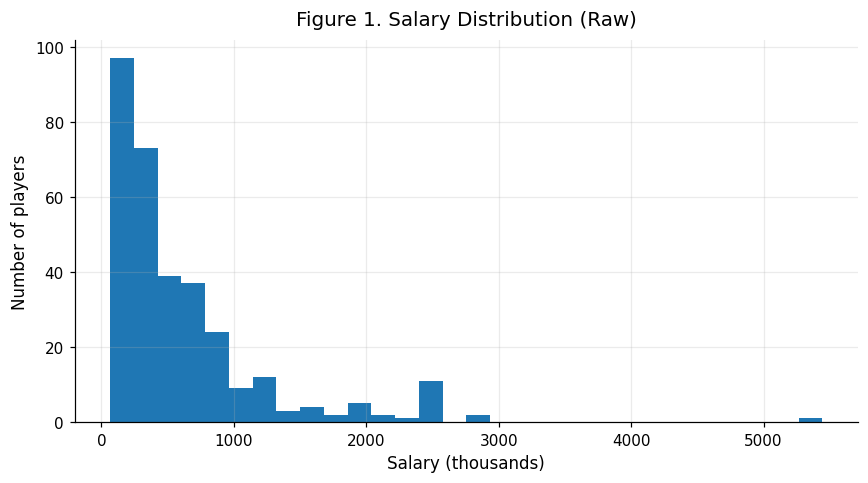

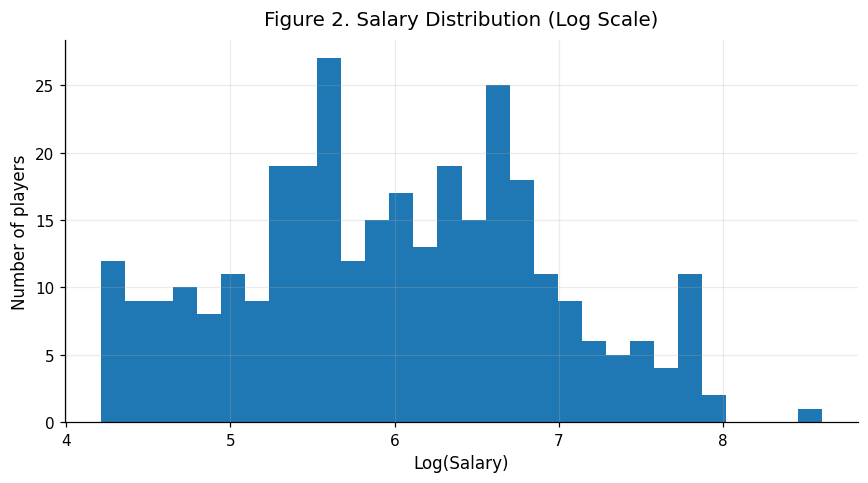

,Salary
25th Percentile,$204.38
50th Percentile (Median),$400.00
75th Percentile,$771.25
Maximum,"$5,444.00"


In [61]:
df_analysis = df.copy()
df_analysis = df_analysis.dropna(subset=["SALARY"]).copy()

df_analysis["LEAGUE"] = df_analysis["LEAGUE"].astype(str).str.strip().str.title()
df_analysis["POSITION"] = df_analysis["POSITION"].astype(str).str.strip().str.upper()
df_analysis["TEAM"] = df_analysis["TEAM"].astype(str).str.strip().str.replace(" ", "", regex=False)

df_analysis["SALARY"] = _as_numeric(df_analysis["SALARY"])
df_analysis = df_analysis.dropna(subset=["SALARY"]).copy()

df_analysis["LOG_SALARY"] = np.log(df_analysis["SALARY"])

df_analysis["EXP_BAND"] = pd.cut(
    df_analysis["YR_MAJOR"],
    bins=[-1, 2, 5, 10, 50],
    labels=["0-2", "3-5", "6-10", "11+"],
    include_lowest=True,
)

print("Analysis dataset shape:", df_analysis.shape)

summary = df_analysis["SALARY"].describe().to_frame("SALARY").T
summary["mean"] = df_analysis["SALARY"].mean()
summary["median"] = df_analysis["SALARY"].median()
summary["skew"] = df_analysis["SALARY"].skew()

_=display_titled_table(
    summary,
    "Salary Summary Statistics",
    "salary_summary_stats",
    currency_cols=["SALARY", "mean", "median"],
    decimals=2,
    index=False,
)

fig, ax = plt.subplots()
ax.hist(df_analysis["SALARY"], bins=30)
ax.set_xlabel("Salary (thousands)")
ax.set_ylabel("Number of players")
save_figure("Salary Distribution (Raw)", "salary_hist_raw", fig=fig, ax=ax)

fig, ax = plt.subplots()
ax.hist(df_analysis["LOG_SALARY"], bins=30)
ax.set_xlabel("Log(Salary)")
ax.set_ylabel("Number of players")
save_figure("Salary Distribution (Log Scale)", "salary_hist_log", fig=fig, ax=ax)

salary_percentiles = df_analysis["SALARY"].quantile([0.25, 0.5, 0.75, 1.0]).to_frame("Salary")
salary_percentiles.index = ["25th Percentile", "50th Percentile (Median)", "75th Percentile", "Maximum"]

_=display_titled_table(
    salary_percentiles,
    "Salary Distribution Percentiles",
    "salary_percentiles",
    currency_cols=["Salary"],
    decimals=2,
    index=True,
)

### Method 2: Crosstabs and Group Summaries

,count,mean,median,std
LEAGUE,,,,
American,175,$643.03,$400.00,$647.84
National,147,$579.85,$400.00,$646.37


,count,mean,median,std
POSITION,,,,
S3,1,$875.00,$875.00,
RF,26,$714.26,$666.25,$418.24
2B,31,$582.49,$550.00,$368.67
CF,26,$647.24,$545.00,$609.43
1B,31,$828.35,$535.00,$745.53
3B,32,$666.70,$475.00,$613.45
3O,1,$450.00,$450.00,
LF,25,$736.45,$400.00,$811.18
DH,16,$608.12,$395.00,$567.32


,count,mean,median,std
EXP_BAND,,,,
0-2,43,$201.31,$110.00,$389.65
3-5,93,$449.03,$254.00,$546.39
6-10,96,$697.82,$600.00,$514.67
11+,90,$892.90,$700.00,$805.94


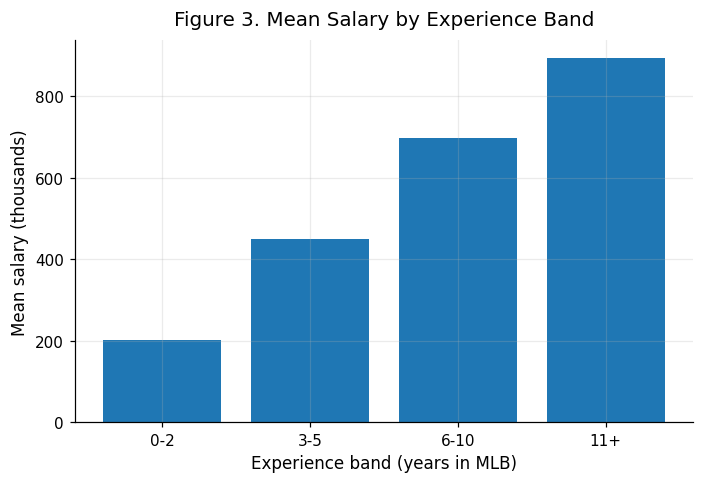

,count,mean,median,std
TEAM,,,,
Baltimore,15,"$1,023.27",$489.00,$984.39
LosAngeles,14,$876.64,$534.25,"$1,355.28"
Boston,11,$810.68,$776.67,$709.42
Minneapolis,13,$796.00,$365.00,$873.12
NewYork,32,$765.75,$398.75,$751.01
Oakland,12,$757.92,$512.50,$729.70
Milwaukee,19,$664.39,$288.00,$805.48
Detroit,12,$659.82,$468.57,$647.53
Cincinnati,12,$639.18,$620.00,$547.32


In [62]:
league_summary = (
    df_analysis.groupby("LEAGUE")["SALARY"]
    .agg(count="count", mean="mean", median="median", std="std")
)

_=display_titled_table(
    league_summary,
    "Salary Summary by League",
    "salary_by_league",
    currency_cols=["mean", "median", "std"],
    decimals=2,
    index=True,
)

pos_summary = (
    df_analysis.groupby("POSITION", observed=True)["SALARY"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("median", ascending=False)
)

_=display_titled_table(
    pos_summary,
    "Salary Summary by Position",
    "salary_by_position",
    currency_cols=["mean", "median", "std"],
    decimals=2,
    index=True,
)

exp_summary = (
    df_analysis.groupby("EXP_BAND", observed=True)["SALARY"]
    .agg(count="count", mean="mean", median="median", std="std")
)

_=display_titled_table(
    exp_summary,
    "Salary Summary by Experience Band",
    "salary_by_experience_band",
    currency_cols=["mean", "median", "std"],
    decimals=2,
    index=True,
)

exp_means = df_analysis.groupby("EXP_BAND", observed=True)["SALARY"].mean()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(exp_means.index.astype(str), exp_means.values)
ax.set_xlabel("Experience band (years in MLB)")
ax.set_ylabel("Mean salary (thousands)")
save_figure("Mean Salary by Experience Band", "mean_salary_by_experience_band", fig=fig, ax=ax)

team_summary = (
    df_analysis.groupby("TEAM", observed=True)["SALARY"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

_=display_titled_table(
    team_summary,
    "Salary Summary by Team",
    "salary_by_team",
    currency_cols=["mean", "median", "std"],
    decimals=2,
    index=True,
)

### Method 3: Correlation Analysis

,Correlation_with_Salary
CR_RBI,0.451
CR_RUNS,0.450
CR_HITS,0.447
CR_ATBAT,0.436
CR_HOME,0.408


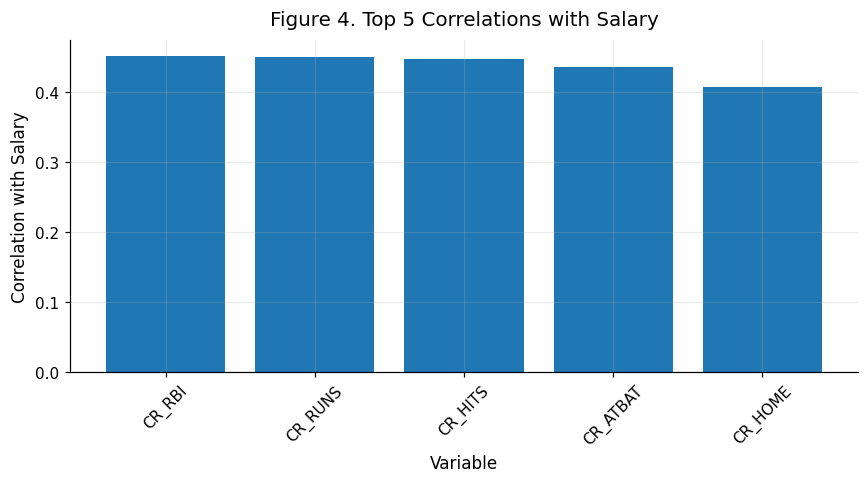

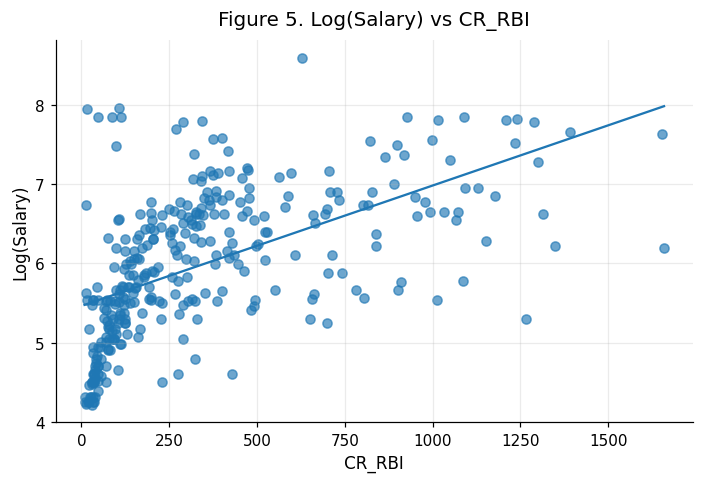

In [63]:
numeric_cols = [
    "NO_ATBAT", "NO_HITS", "NO_HOME", "NO_RUNS", "NO_RBI", "NO_BB", "YR_MAJOR",
    "CR_ATBAT", "CR_HITS", "CR_HOME", "CR_RUNS", "CR_RBI", "CR_BB"
]

corr_series = (
    df_analysis[numeric_cols + ["SALARY"]]
    .corr(numeric_only=True)["SALARY"]
    .drop("SALARY")
    .sort_values(ascending=False)
)

top_corr = corr_series.head(5).to_frame("Correlation_with_Salary")

_=display_titled_table(
    top_corr,
    "Top Correlations with Salary",
    "top_correlations",
    corr_cols=["Correlation_with_Salary"],
    decimals=3,
    index=True,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(top_corr.index.astype(str), top_corr["Correlation_with_Salary"].values)
ax.set_xlabel("Variable")
ax.set_ylabel("Correlation with Salary")
ax.tick_params(axis="x", rotation=45)
save_figure("Top 5 Correlations with Salary", "top5_correlations", fig=fig, ax=ax)

best_x = top_corr.index[0]
plot_df = df_analysis[[best_x, "LOG_SALARY"]].dropna().sort_values(best_x)

x = plot_df[best_x].to_numpy()
y = plot_df["LOG_SALARY"].to_numpy()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(x, y, alpha=0.65)
m, b = np.polyfit(x, y, 1)
ax.plot(x, m * x + b)
ax.set_xlabel(str(best_x))
ax.set_ylabel("Log(Salary)")
_=save_figure(f"Log(Salary) vs {best_x}", f"scatter_logsalary_vs_{best_x}", fig=fig, ax=ax)

### Method 4: Two-Sample t-test (League Comparison)

In [64]:
group_A = df_analysis.loc[df_analysis["LEAGUE"] == "American", "SALARY"].dropna()
group_N = df_analysis.loc[df_analysis["LEAGUE"] == "National", "SALARY"].dropna()

t_stat, p_value = stats.ttest_ind(group_A, group_N, equal_var=False, nan_policy="omit")

ttest_summary = pd.DataFrame({
    "League": ["American", "National"],
    "Count": [group_A.shape[0], group_N.shape[0]],
    "Mean Salary": [group_A.mean(), group_N.mean()],
    "Median Salary": [group_A.median(), group_N.median()],
    "Std Dev": [group_A.std(), group_N.std()],
})

_=display_titled_table(
    ttest_summary,
    "League Salary Comparison (Welch t-test)",
    "league_ttest_summary",
    currency_cols=["Mean Salary", "Median Salary", "Std Dev"],
    decimals=0,
    index=False,
)

print("Welch t-test t-statistic:", round(float(t_stat), 4))
print("Welch t-test p-value:", round(float(p_value), 4))
print("American mean:", round(group_A.mean(), 2), "National mean:", round(group_N.mean(), 2))

,League,Count,Mean Salary,Median Salary,Std Dev
0,American,175,$643.03,$400.00,$647.84
1,National,147,$579.85,$400.00,$646.37


Welch t-test t-statistic: 0.8727
Welch t-test p-value: 0.3835
American mean: 643.03 National mean: 579.85


### Method 5: ANOVA (Group Differences by Position and Team)

In [65]:
anova_pos = ols("SALARY ~ C(POSITION)", data=df_analysis).fit()
anova_pos_table = sm.stats.anova_lm(anova_pos, typ=2)
anova_pos_table["eta_sq"] = anova_pos_table["sum_sq"] / anova_pos_table["sum_sq"].sum()

_=display_titled_table(
    anova_pos_table,
    "ANOVA: Salary by Position (with Eta-Squared)",
    "anova_salary_by_position",
    decimals=4,
    index=True,
    folder="tables",
)

anova_team = ols("SALARY ~ C(TEAM)", data=df_analysis).fit()
anova_team_table = sm.stats.anova_lm(anova_team, typ=2)
anova_team_table["eta_sq"] = anova_team_table["sum_sq"] / anova_team_table["sum_sq"].sum()

_=display_titled_table(
    anova_team_table,
    "ANOVA: Salary by Team (with Eta-Squared)",
    "anova_salary_by_team",
    decimals=4,
    index=True,
    folder="appendix",
)

,sum_sq,df,F,PR(>F),eta_sq
C(POSITION),"8,783,029.9908",24.0000,0.8656,0.6496,0.0654
Residual,"125,562,203.5516",297.0000,,,0.9346


,sum_sq,df,F,PR(>F),eta_sq
C(TEAM),"10,566,326.1749",22.0000,1.1602,0.2829,0.0787
Residual,"123,778,907.3674",299.0000,,,0.9213


### Method 6: Multiple Regression (Experience, Position, and Performance)

                            OLS Regression Results                            
Dep. Variable:             LOG_SALARY   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     5.542
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           5.20e-14
Time:                        21:58:17   Log-Likelihood:                -371.48
No. Observations:                 322   AIC:                             795.0
Df Residuals:                     296   BIC:                             893.1
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.5052      0.80

,Model,R2,Adj R2,AIC,BIC
0,Model A,0.319,0.261,794.957,893.095
1,Model B,0.378,0.319,771.495,880.957


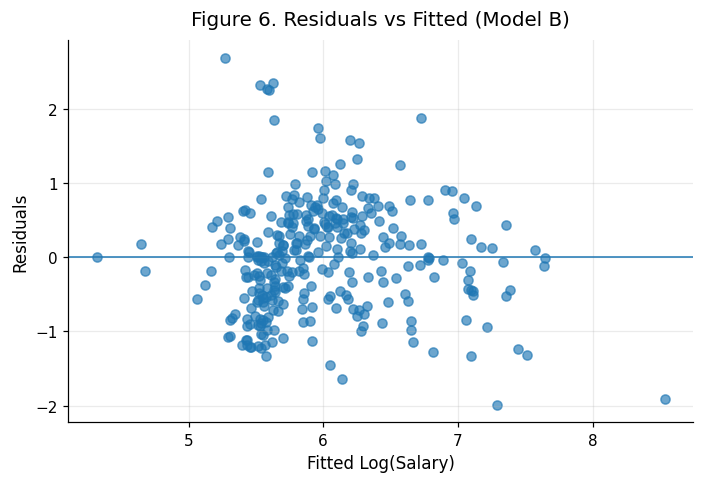

In [66]:
model_basic = ols("LOG_SALARY ~ YR_MAJOR + C(POSITION)", data=df_analysis).fit()
model_full = ols("LOG_SALARY ~ YR_MAJOR + C(POSITION) + CR_RBI + CR_HOME + CR_RUNS", data=df_analysis).fit()

print(model_basic.summary())
print(model_full.summary())

save_text_output(model_basic.summary().as_text(), "regression_model_basic", folder="models")
save_text_output(model_full.summary().as_text(), "regression_model_full", folder="models")

reg_compare = pd.DataFrame({
    "Model": ["Model A", "Model B"],
    "R2": [model_basic.rsquared, model_full.rsquared],
    "Adj R2": [model_basic.rsquared_adj, model_full.rsquared_adj],
    "AIC": [model_basic.aic, model_full.aic],
    "BIC": [model_basic.bic, model_full.bic],
})

_=display_titled_table(
    reg_compare,
    "Regression Model Comparison",
    "regression_model_comparison",
    decimals=3,
    index=False,
)

fitted = model_full.fittedvalues
resid = model_full.resid

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(fitted, resid, alpha=0.65)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Fitted Log(Salary)")
ax.set_ylabel("Residuals")
_=save_figure("Residuals vs Fitted (Model B)", "residuals_vs_fitted_modelB", fig=fig, ax=ax)